# 04 - Individual Subject RDMs (CLIP + DINOv3)

This notebook computes and visualizes individual-subject RDMs using the same category order files produced in notebook `03_bv_things_rdm_comparison.ipynb` (under `main_results_valid129s_04302026/results/`, `*_filtered-0.27_valid129.csv`).

Per-kid embeddings match notebooks **08** / **09**: `clip_embeddings_new`, `facebook_dinov3-vitb16-pretrain-lvd1689m`, and `babydinov3_grad_accum_1/step_{checkpoint}` under `/data2/dataset/babyview/868_hours/outputs/yoloe_cdi_embeddings/`. Category-level z-scored BabyDINOv3 tables from notebook **06** live at `exemplar_set_embeddings/{valid85|valid129}/bv_babydinov3_exemplar_avg_zscore_within_{...}.csv`. Tables and figures are written to that run’s `results/` and `figures/` directories.

For **both CLIP and DINOv3**, it provides:
- all-subject RDM panel (missing categories shown as empty cells)
- top-8 densest-subject RDM panel
- pairwise RDM correlations across all subjects and top-8 subjects
- both **Pearson** and **Spearman rank** correlations

In [14]:
from __future__ import annotations

from pathlib import Path
from collections import defaultdict
from itertools import combinations
import os
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm

In [15]:
# Paths and constants (aligned with notebook 01 setup conventions)
PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = PROJECT_ROOT / 'data'
ANALYSIS_DIR = PROJECT_ROOT / 'analysis'
PREPRINT_DIR = ANALYSIS_DIR / 'manuscript-2026'

# Set this once at the top of the notebook.
# Supported values: "valid129" (default) or "valid85"
CATEGORY_SET = 'valid129'

CATEGORY_FILES = {
    'valid85': DATA_DIR / 'included_categories_valid85.txt',
    'valid129': DATA_DIR / 'included_categories_valid129.txt',
}
if CATEGORY_SET not in CATEGORY_FILES:
    raise ValueError(
        f"Unsupported CATEGORY_SET: {CATEGORY_SET!r} (expected one of {sorted(CATEGORY_FILES)})"
    )
INCLUDED_CATEGORIES_TXT = CATEGORY_FILES[CATEGORY_SET]

if CATEGORY_SET == 'valid129':
    MAIN_RESULTS_DIR = PREPRINT_DIR / 'main_results_valid129s_04302026'
else:
    MAIN_RESULTS_DIR = PREPRINT_DIR / 'supplemental_results_valid85cats_04302026'

RESULTS_DIR = MAIN_RESULTS_DIR / 'results'
FIGURES_DIR = MAIN_RESULTS_DIR / 'figures'

THRESHOLD_TOKEN = '0.27'
RUN_SUFFIX = f'filtered-{THRESHOLD_TOKEN}_{CATEGORY_SET}'

YOLOE_ROOT = Path('/data2/dataset/babyview/868_hours/outputs/yoloe_cdi_embeddings')
EXEMPLAR_EMBED_DIR = PREPRINT_DIR / 'exemplar_set_embeddings' / CATEGORY_SET
BABYDINOV3_CHECKPOINT_STEP = os.environ.get('BV_BABYDINOV3_CHECKPOINT_STEP', '119999').strip()
BABYDINOV3_EMBEDDINGS_DIR = YOLOE_ROOT / 'babydinov3_grad_accum_1' / f'step_{BABYDINOV3_CHECKPOINT_STEP}'
BABYDINOV3_BV_ZSCORE_CSV = EXEMPLAR_EMBED_DIR / f'bv_babydinov3_exemplar_avg_zscore_within_{CATEGORY_SET}.csv'
BABYDINOV3_ORDER_CSV = RESULTS_DIR / f'bv_things_rdm_order_bv_semantic_babydinov3_{RUN_SUFFIX}.csv'
MODEL_CONFIGS = {
    'clip': {
        'order_csv': RESULTS_DIR / f'bv_things_rdm_order_bv_semantic_clip_{RUN_SUFFIX}.csv',
        'embeddings_dir': YOLOE_ROOT / 'clip_embeddings_new',
    },
    'dinov3': {
        'order_csv': RESULTS_DIR / f'bv_things_rdm_order_bv_semantic_dinov3_{RUN_SUFFIX}.csv',
        'embeddings_dir': YOLOE_ROOT / 'facebook_dinov3-vitb16-pretrain-lvd1689m',
    },
}

TRAJECTORY_CSV = ANALYSIS_DIR / 'individual_analyses' / 'developmental_trajectory_rdms_clip' / 'trajectory_correlations.csv'
EXCLUDED_SUBJECT = '00270001'
N_TOP_DENSEST = 8
MIN_CATEGORIES_PER_SUBJECT = 10

# Raw `.npy` trees: limit which subjects are read from disk (big speedup). Requires the trajectory cell to be run first
# (`ranked_density_df`). None = load everyone. Use a small int for fast raw runs (e.g. 8 = only trajectory top-8, risky if
# some lack MIN_CATEGORIES; use 16–24 if you need a buffer so the top-8 panel always fills).
TRAJECTORY_TOP_K_EMBED_LOAD: int | None = 8

# Parallel np.load — raw trees have many small .npy files per category; this is usually the main bottleneck.
EMBED_LOAD_MAX_WORKERS = max(4, min(16, (os.cpu_count() or 8)))

# Z-score (notebook 06): L2 each exemplar, mean per category, then z-score each **dimension across categories**.
# Done **separately for each subject** using only that subject's category means — not pooled across kids or the
# trajectory filter. Same *type* of transform as 06's one BV table, applied per child (fair for cross-subject RDM compare).
ZSCORE_EMBEDDINGS_ACROSS_CATEGORIES = True

# Speed: random subsample of exemplars per (subject, category) before averaging (None = use all). Same rule for every kid.
MAX_EXEMPLARS_PER_CATEGORY: int | None = 128
EXEMPLAR_SUBSAMPLE_SEED = 42

# Speed: load several category directories concurrently (good on NVMe). Inner per-category np.load pool is reduced when on.
EMBED_PARALLEL_CATEGORIES = True
EMBED_CATEGORY_MAX_WORKERS = min(8, max(2, (os.cpu_count() or 4) // 2))

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"[04_individual_rdms] CATEGORY_SET={CATEGORY_SET!r}")
print(f"Included categories txt: {INCLUDED_CATEGORIES_TXT}")

for model_name, cfg in MODEL_CONFIGS.items():
    print(f"[{model_name}] order csv: {cfg['order_csv']} (exists: {cfg['order_csv'].exists()})")
    print(f"[{model_name}] embeddings: {cfg['embeddings_dir']} (exists: {cfg['embeddings_dir'].exists()})")
print(f'[babydinov3] order csv: {BABYDINOV3_ORDER_CSV} (exists: {BABYDINOV3_ORDER_CSV.exists()})')
print(f'[babydinov3] per-crop embeddings: {BABYDINOV3_EMBEDDINGS_DIR} (exists: {BABYDINOV3_EMBEDDINGS_DIR.is_dir()})')
print(f'[babydinov3] exemplar z-score csv: {BABYDINOV3_BV_ZSCORE_CSV} (exists: {BABYDINOV3_BV_ZSCORE_CSV.exists()})')
print(f'Main results root: {MAIN_RESULTS_DIR}')
print(f'Trajectory CSV: {TRAJECTORY_CSV} (exists: {TRAJECTORY_CSV.exists()})')
print(f'ZSCORE_EMBEDDINGS_ACROSS_CATEGORIES (notebook-06 style): {ZSCORE_EMBEDDINGS_ACROSS_CATEGORIES}')
print(f'MAX_EXEMPLARS_PER_CATEGORY (speed): {MAX_EXEMPLARS_PER_CATEGORY}')
print(f'EMBED_PARALLEL_CATEGORIES / workers: {EMBED_PARALLEL_CATEGORIES} / {EMBED_CATEGORY_MAX_WORKERS}')


[04_individual_rdms] CATEGORY_SET='valid129'
Included categories txt: /home/j7yang/babyview-projects/vss2026/object-detection/data/included_categories_valid129.txt
[clip] order csv: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/results/bv_things_rdm_order_bv_semantic_clip_filtered-0.27_valid129.csv (exists: True)
[clip] embeddings: /data2/dataset/babyview/868_hours/outputs/yoloe_cdi_embeddings/clip_embeddings_new (exists: True)
[dinov3] order csv: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/results/bv_things_rdm_order_bv_semantic_dinov3_filtered-0.27_valid129.csv (exists: True)
[dinov3] embeddings: /data2/dataset/babyview/868_hours/outputs/yoloe_cdi_embeddings/facebook_dinov3-vitb16-pretrain-lvd1689m (exists: True)
Main results root: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026
Traject

In [16]:
def load_order(order_csv: Path):
    order_df = pd.read_csv(order_csv).sort_values('position').reset_index(drop=True)
    ordered_categories = order_df['category'].astype(str).str.strip().str.lower().tolist()
    category_to_idx = {c: i for i, c in enumerate(ordered_categories)}
    return order_df, ordered_categories, category_to_idx


def parse_subject_id_from_embedding_stem(stem: str) -> str | None:
    """Parse subject id from per-exemplar `.npy` stem (YOLOE `clip_embeddings_new` / DINO layout, or legacy subject-first names)."""
    parts = stem.split('_')
    if len(parts) >= 6:
        sid = parts[2].strip()
        if sid.isdigit():
            return sid.zfill(8)
    if parts and parts[0].strip().isdigit():
        return parts[0].strip().zfill(8)
    return None


def _stem_quick_maybe_subject(stem: str, allow: set[str]) -> bool:
    """Fast reject of stems that cannot be one of `allow` (before split/parse)."""
    for sid in allow:
        if stem.startswith(f'{sid}_') or f'_{sid}_' in stem:
            return True
    return False


def _iter_category_npy_paths(cat_dir: Path, subject_ids_filter: set[str] | None):
    if subject_ids_filter is None:
        yield from cat_dir.glob('*.npy')
        return
    with os.scandir(cat_dir) as it:
        for entry in it:
            if not entry.is_file(follow_symlinks=False):
                continue
            name = entry.name
            if not name.endswith('.npy'):
                continue
            stem = name[:-4]
            if not _stem_quick_maybe_subject(stem, subject_ids_filter):
                continue
            yield Path(entry.path)


def _load_npy_task(item: tuple[Path, str]):
    path, subject_id = item
    try:
        return subject_id, np.load(path)
    except Exception:
        return None


def _l2_normalize_vec(v: np.ndarray) -> np.ndarray:
    x = np.asarray(v, dtype=np.float64).ravel()
    n = np.linalg.norm(x)
    return x / n if n > 0 else x


def zscore_rows_across_categories(X: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    """Z-score each column across rows (same as notebook 06 `zscore_rows` on category × dim matrix)."""
    mu = X.mean(axis=0)
    sig = X.std(axis=0)
    return (X - mu) / (sig + eps)


def zscore_subject_embedding_dict(cat_to_vec: dict[str, np.ndarray], eps: float = 1e-10) -> dict[str, np.ndarray]:
    if len(cat_to_vec) < 2:
        return dict(cat_to_vec)
    cats = sorted(cat_to_vec.keys())
    X = np.stack([np.asarray(cat_to_vec[c], dtype=np.float64).ravel() for c in cats], axis=0)
    Xz = zscore_rows_across_categories(X, eps=eps)
    return {c: Xz[i] for i, c in enumerate(cats)}


def _load_vectors_for_one_category(
    cat_dir: Path,
    subject_ids_filter: set[str] | None,
    excluded_subject: str | None,
    inner_workers: int,
) -> tuple[str, dict[str, list[np.ndarray]]]:
    """Load all .npy for one category folder into lists keyed by subject_id."""
    category = cat_dir.name.strip().lower()
    sid_to_vecs: dict[str, list[np.ndarray]] = defaultdict(list)
    batch: list[tuple[Path, str]] = []
    for emb_file in _iter_category_npy_paths(cat_dir, subject_ids_filter):
        subject_id = parse_subject_id_from_embedding_stem(emb_file.stem)
        if subject_id is None:
            continue
        if excluded_subject and subject_id == excluded_subject:
            continue
        if subject_ids_filter is not None and subject_id not in subject_ids_filter:
            continue
        batch.append((emb_file, subject_id))

    if not batch:
        return category, {}

    iw = max(1, inner_workers)
    if iw <= 1 or len(batch) < 12:
        for path, subject_id in batch:
            r = _load_npy_task((path, subject_id))
            if r is None:
                continue
            sid, emb = r
            sid_to_vecs[sid].append(emb)
    else:
        chunksize = max(1, min(256, len(batch) // (iw * 4)))
        with ThreadPoolExecutor(max_workers=iw) as pool:
            for r in pool.map(_load_npy_task, batch, chunksize=chunksize):
                if r is None:
                    continue
                sid, emb = r
                sid_to_vecs[sid].append(emb)

    return category, dict(sid_to_vecs)


def load_subject_category_embeddings(
    normalized_embeddings_dir: Path,
    allowed_categories: set[str],
    excluded_subject: str | None = None,
    subject_ids_filter: set[str] | None = None,
    max_load_workers: int | None = None,
):
    """Per exemplar → mean/category → optional z-score (06). Parallel np.load; optional parallel category folders."""
    workers = EMBED_LOAD_MAX_WORKERS if max_load_workers is None else max_load_workers
    subject_category_embeddings = defaultdict(lambda: defaultdict(list))

    category_dirs = sorted(
        [p for p in normalized_embeddings_dir.iterdir() if p.is_dir() and p.name.strip().lower() in allowed_categories],
        key=lambda p: p.name.lower(),
    )
    desc = f'Loading categories from {normalized_embeddings_dir.name}'
    use_parallel_cat = (
        EMBED_PARALLEL_CATEGORIES and len(category_dirs) >= 4 and EMBED_CATEGORY_MAX_WORKERS > 1
    )
    if use_parallel_cat:
        # One worker per category folder; avoid nested thread storms (inner loads are sequential here).
        def _one(cd: Path):
            return _load_vectors_for_one_category(cd, subject_ids_filter, excluded_subject, 1)

        with ThreadPoolExecutor(max_workers=EMBED_CATEGORY_MAX_WORKERS) as pool:
            futs = {pool.submit(_one, cd): cd for cd in category_dirs}
            for fut in tqdm(as_completed(futs), total=len(category_dirs), desc=desc):
                category, sid_map = fut.result()
                for sid, vecs in sid_map.items():
                    subject_category_embeddings[sid][category].extend(vecs)
    else:
        for cat_dir in tqdm(category_dirs, desc=desc):
            category, sid_map = _load_vectors_for_one_category(cat_dir, subject_ids_filter, excluded_subject, workers)
            for sid, vecs in sid_map.items():
                subject_category_embeddings[sid][category].extend(vecs)

    rng = np.random.default_rng(EXEMPLAR_SUBSAMPLE_SEED)
    raw_means: dict[str, dict[str, np.ndarray]] = {}
    for sid, cat_dict in tqdm(subject_category_embeddings.items(), desc='Averaging by subject'):
        raw_means[sid] = {}
        for cat, emb_list in cat_dict.items():
            if len(emb_list) == 0:
                continue
            el = emb_list
            if MAX_EXEMPLARS_PER_CATEGORY is not None and len(emb_list) > MAX_EXEMPLARS_PER_CATEGORY:
                pick = rng.choice(len(emb_list), size=MAX_EXEMPLARS_PER_CATEGORY, replace=False)
                el = [emb_list[i] for i in sorted(pick.tolist())]
            if ZSCORE_EMBEDDINGS_ACROSS_CATEGORIES:
                arr = np.stack([_l2_normalize_vec(e) for e in el], axis=0)
            else:
                arr = np.stack([e.ravel() for e in el], axis=0)
            mean_emb = arr.mean(axis=0)
            raw_means[sid][cat] = mean_emb

    subject_embeddings: dict[str, dict[str, np.ndarray]] = {}
    for sid, cat_dict in raw_means.items():
        if ZSCORE_EMBEDDINGS_ACROSS_CATEGORIES:
            subject_embeddings[sid] = zscore_subject_embedding_dict(cat_dict)
        else:
            subject_embeddings[sid] = {}
            for cat, mean_emb in cat_dict.items():
                norm = np.linalg.norm(mean_emb)
                subject_embeddings[sid][cat] = (mean_emb / norm) if norm > 0 else mean_emb

    return subject_embeddings


def compute_subject_rdm_with_missing(subject_embeds: dict[str, np.ndarray], ordered_cats: list[str], category_to_idx: dict[str, int]):
    n = len(ordered_cats)
    rdm = np.full((n, n), np.nan, dtype=float)

    available = [c for c in ordered_cats if c in subject_embeds]
    if len(available) < 2:
        return rdm, available

    X = np.stack([subject_embeds[c] for c in available], axis=0)
    d = squareform(pdist(X, metric='cosine'))

    idx = [category_to_idx[c] for c in available]
    for i, ii in enumerate(idx):
        for j, jj in enumerate(idx):
            rdm[ii, jj] = d[i, j]

    return rdm, available


def vectorize_lower_triangle_for_categories(rdm: np.ndarray, idx: list[int]):
    sub = rdm[np.ix_(idx, idx)]
    il = np.tril_indices(len(idx), k=-1)
    return sub[il]


def pairwise_rdm_correlations(rdms: dict[str, np.ndarray], available_map: dict[str, set[str]], category_to_idx: dict[str, int]):
    rows = []
    subjects = sorted(rdms.keys())
    for a, b in combinations(subjects, 2):
        common = sorted(available_map[a].intersection(available_map[b]))
        if len(common) < 3:
            continue
        idx = [category_to_idx[c] for c in common]
        va = vectorize_lower_triangle_for_categories(rdms[a], idx)
        vb = vectorize_lower_triangle_for_categories(rdms[b], idx)
        if len(va) < 3:
            continue

        pr, pp = pearsonr(va, vb)
        sr, sp = spearmanr(va, vb)

        rows.append({
            'subject_a': a,
            'subject_b': b,
            'n_common_categories': len(common),
            'n_rdm_pairs': len(va),
            'pearson_r': float(pr),
            'pearson_p': float(pp),
            'spearman_rho': float(sr),
            'spearman_p': float(sp),
        })
    return pd.DataFrame(rows)


def summarize_pairwise(df: pd.DataFrame, group_name: str, n_subjects: int):
    return {
        'group': group_name,
        'n_subjects': int(n_subjects),
        'n_subject_pairs': int(len(df)),
        'avg_pearson_r': float(df['pearson_r'].mean()) if len(df) else np.nan,
        'std_pearson_r': float(df['pearson_r'].std(ddof=1)) if len(df) > 1 else np.nan,
        'avg_spearman_rho': float(df['spearman_rho'].mean()) if len(df) else np.nan,
        'std_spearman_rho': float(df['spearman_rho'].std(ddof=1)) if len(df) > 1 else np.nan,
        'avg_common_categories': float(df['n_common_categories'].mean()) if len(df) else np.nan,
        'avg_rdm_pairs': float(df['n_rdm_pairs'].mean()) if len(df) else np.nan,
    }


def plot_subject_rdm_grid(subject_ids, subject_rdms, available_map, title, out_prefix, ncols=6, figsize_scale=2.6):
    n = len(subject_ids)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * figsize_scale, nrows * figsize_scale), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color='white')

    vmin, vmax = 0.0, 2.0
    last_im = None

    for i, sid in enumerate(subject_ids):
        ax = axes[i]
        rdm = np.ma.masked_invalid(subject_rdms[sid])
        last_im = ax.imshow(rdm, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest', aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f'{sid} (n={len(available_map[sid])})', fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    cbar = fig.colorbar(last_im, ax=axes.tolist(), fraction=0.02, pad=0.01)
    cbar.set_label('Cosine distance', rotation=90)
    fig.suptitle(title, fontsize=14)

    # Do not use Path.with_suffix: stems like `...filtered-0.27` make `.suffix` == `.27` and corrupt the path.
    png = Path(str(out_prefix) + '.png')
    pdf = Path(str(out_prefix) + '.pdf')
    fig.savefig(png, dpi=200, bbox_inches='tight')
    fig.savefig(pdf, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    return png, pdf


def plot_pairwise_top8_heatmap_hist(pairwise_csv: Path, model_name: str):
    df = pd.read_csv(pairwise_csv)
    subjects = sorted(set(df['subject_a']).union(set(df['subject_b'])))

    mat = pd.DataFrame(np.eye(len(subjects)), index=subjects, columns=subjects, dtype=float)
    for _, row in df.iterrows():
        a, b, r = row['subject_a'], row['subject_b'], row['pearson_r']
        mat.loc[a, b] = r
        mat.loc[b, a] = r

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    im = ax1.imshow(mat.values, cmap='viridis', vmin=0.7, vmax=1.0)
    ax1.set_xticks(np.arange(len(subjects)))
    ax1.set_yticks(np.arange(len(subjects)))
    ax1.set_xticklabels(subjects, rotation=45, ha='right', fontsize=8)
    ax1.set_yticklabels(subjects, fontsize=8)
    ax1.set_title(f'{model_name.upper()} top-8: pairwise Pearson RDM correlation')

    for i in range(len(subjects)):
        for j in range(len(subjects)):
            ax1.text(j, i, f"{mat.values[i, j]:.2f}", ha='center', va='center', fontsize=7, color='white')

    cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
    cbar.set_label('Pearson r')

    ax2.hist(df['pearson_r'], bins=10, color='#4C72B0', edgecolor='white', alpha=0.8, label='Pearson')
    ax2.hist(df['spearman_rho'], bins=10, color='#55A868', edgecolor='white', alpha=0.6, label='Spearman')
    ax2.axvline(df['pearson_r'].mean(), color='#1F4E8A', linestyle='--', linewidth=2, label=f"Pearson mean={df['pearson_r'].mean():.3f}")
    ax2.axvline(df['spearman_rho'].mean(), color='#2E7D32', linestyle='--', linewidth=2, label=f"Spearman mean={df['spearman_rho'].mean():.3f}")
    ax2.set_title(f'{model_name.upper()} top-8: correlation distributions')
    ax2.set_xlabel('Correlation')
    ax2.set_ylabel('Count')
    ax2.legend()

    out_png = FIGURES_DIR / f'individual_rdm_pairwise_top8_heatmap_hist_{model_name}_{RUN_SUFFIX}.png'
    out_pdf = FIGURES_DIR / f'individual_rdm_pairwise_top8_heatmap_hist_{model_name}_{RUN_SUFFIX}.pdf'
    fig.savefig(out_png, dpi=220, bbox_inches='tight')
    fig.savefig(out_pdf, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f'Saved: {out_png}')
    print(f'Saved: {out_pdf}')
    print(f"Mean Pearson r ({model_name}, top-8): {df['pearson_r'].mean():.6f}")
    print(f"Mean Spearman rho ({model_name}, top-8): {df['spearman_rho'].mean():.6f}")

In [17]:
# Top-8 densest subjects (shared across models; from trajectory file)
traj_df = pd.read_csv(TRAJECTORY_CSV)
traj_df['subject_id'] = traj_df['subject_id'].astype(str).str.zfill(8)

if 'density' not in traj_df.columns:
    if {'n_categories_younger', 'n_categories_older'}.issubset(set(traj_df.columns)):
        traj_df['density'] = traj_df['n_categories_younger'] + traj_df['n_categories_older']
    else:
        raise ValueError('trajectory_correlations.csv must have either density or younger/older count columns.')

ranked_density_df = (
    traj_df[['subject_id', 'density']]
    .drop_duplicates(subset=['subject_id'])
    .sort_values('density', ascending=False)
)

print('Top candidates by density:')
print(ranked_density_df.head(12).to_string(index=False))

Top candidates by density:
subject_id  density
  00400001      318
  00370002      317
  00320001      316
  00400002      315
  00500001      315
  00510002      313
  00430001      310
  00240001      308
  00370001      308
  00560001      308
  00320003      303
  00420001      302


Embedding load filter: trajectory top-8 subjects only (8 ids) — skips np.load for other kids.

Running model: clip


Computing RDMs (clip): 100%|██████████| 8/8 [00:00<00:00, 82.05it/s]


[clip] included subjects: 8


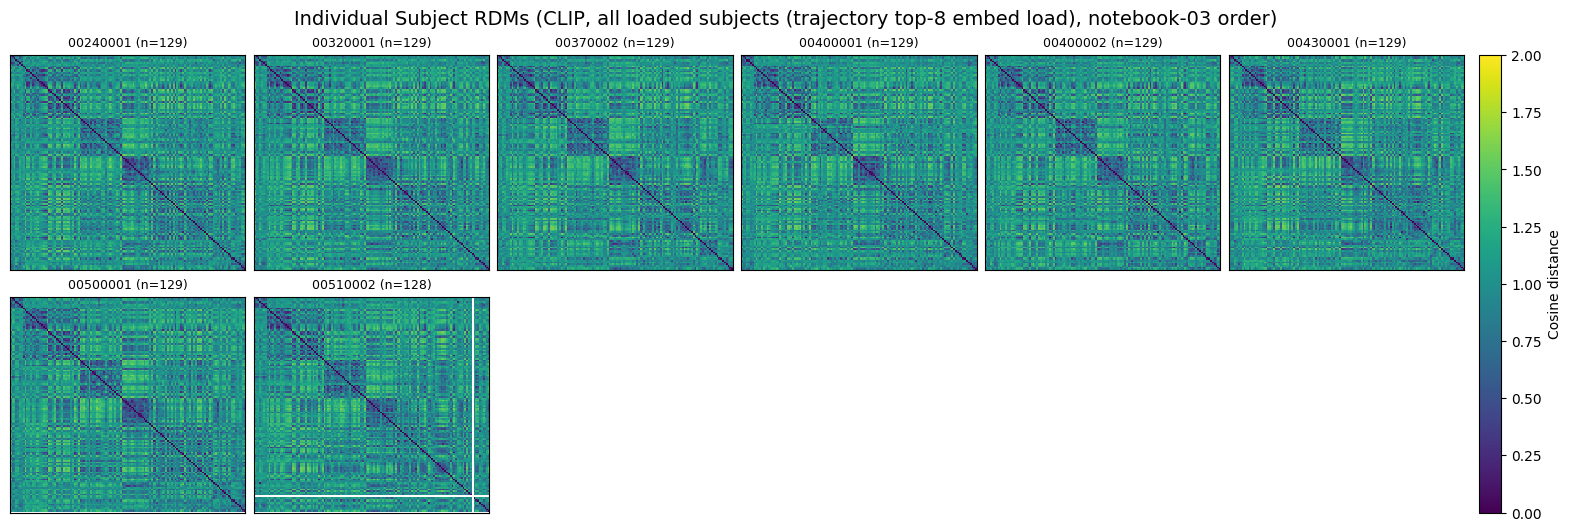

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/individual_rdms_all_subjects_bv_semantic_order_clip_filtered-0.27_valid129.png
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/individual_rdms_all_subjects_bv_semantic_order_clip_filtered-0.27_valid129.pdf
[clip] top-8 densest subjects used: ['00400001', '00370002', '00320001', '00400002', '00500001', '00510002', '00430001', '00240001']


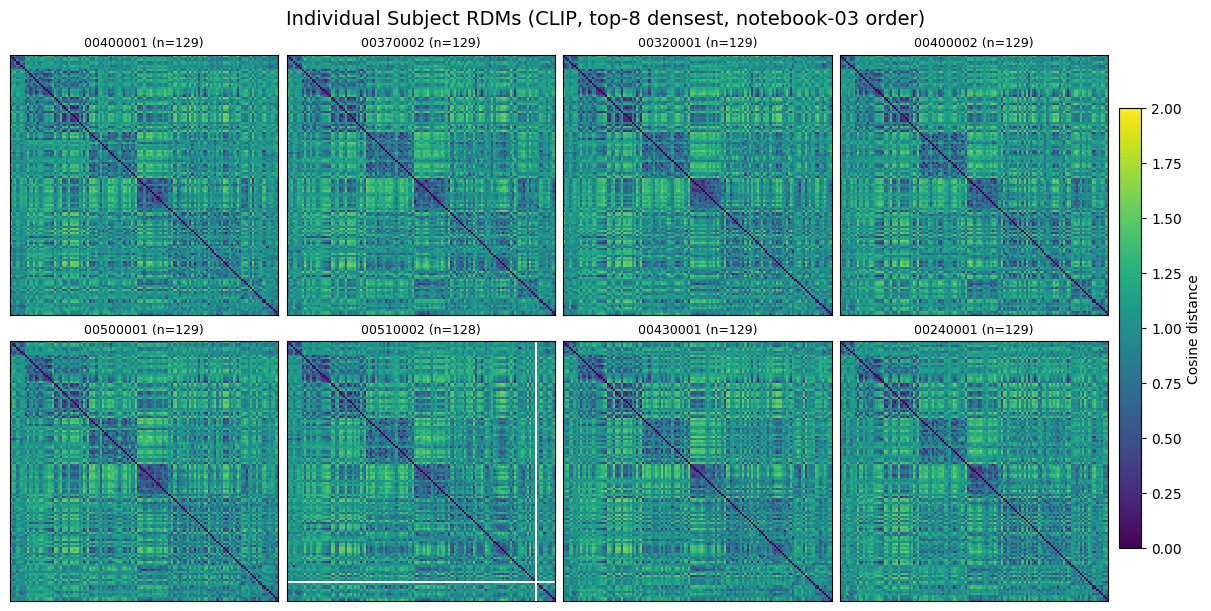

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/individual_rdms_top8_densest_bv_semantic_order_clip_filtered-0.27_valid129.png
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/individual_rdms_top8_densest_bv_semantic_order_clip_filtered-0.27_valid129.pdf
Saved all-subject pairwise CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/results/individual_rdm_pairwise_correlations_all_subjects_clip_filtered-0.27_valid129.csv
Saved top-8 pairwise CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/results/individual_rdm_pairwise_correlations_top8_densest_clip_filtered-0.27_valid129.csv

Running model: dinov3


Loading categories from facebook_dinov3-vitb16-pretrain-lvd1689m: 100%|██████████| 129/129 [16:51<00:00,  7.84s/it]
Computing RDMs (dinov3): 100%|██████████| 8/8 [00:00<00:00, 71.44it/s]


[dinov3] included subjects: 8


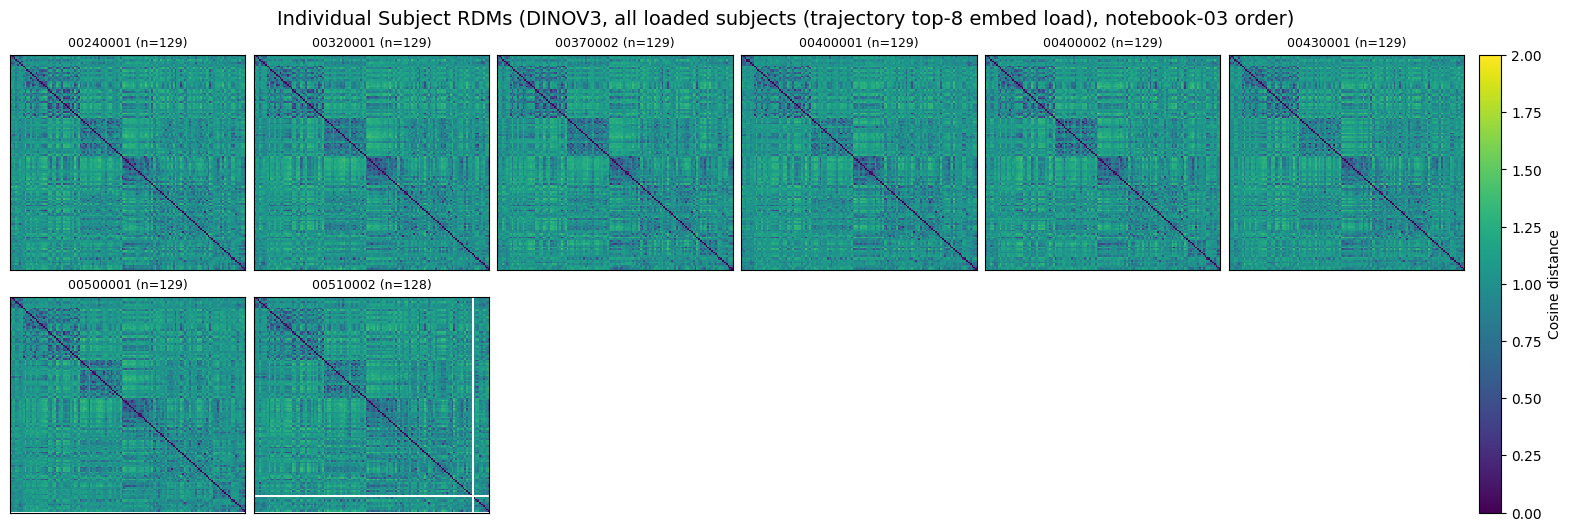

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/individual_rdms_all_subjects_bv_semantic_order_dinov3_filtered-0.27_valid129.png
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/individual_rdms_all_subjects_bv_semantic_order_dinov3_filtered-0.27_valid129.pdf
[dinov3] top-8 densest subjects used: ['00400001', '00370002', '00320001', '00400002', '00500001', '00510002', '00430001', '00240001']


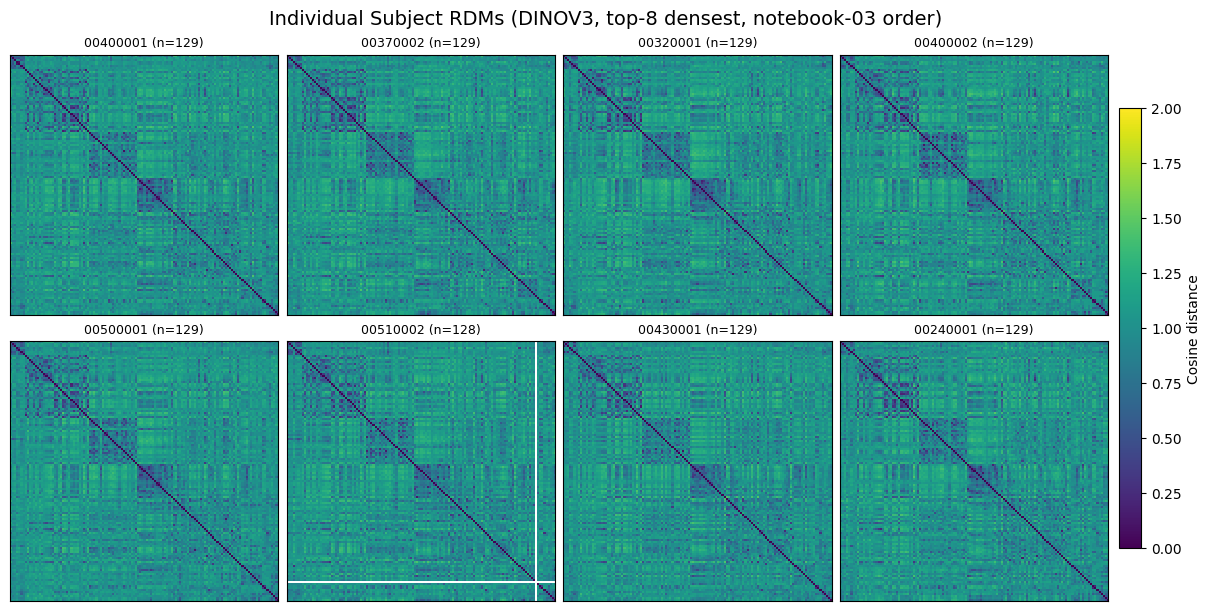

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/individual_rdms_top8_densest_bv_semantic_order_dinov3_filtered-0.27_valid129.png
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/individual_rdms_top8_densest_bv_semantic_order_dinov3_filtered-0.27_valid129.pdf
Saved all-subject pairwise CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/results/individual_rdm_pairwise_correlations_all_subjects_dinov3_filtered-0.27_valid129.csv
Saved top-8 pairwise CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/results/individual_rdm_pairwise_correlations_top8_densest_dinov3_filtered-0.27_valid129.csv


In [18]:
# Run full analysis for each model
all_results = {}
summary_rows = []

if TRAJECTORY_TOP_K_EMBED_LOAD is not None:
    embed_subject_allow = set(
        ranked_density_df.head(TRAJECTORY_TOP_K_EMBED_LOAD)['subject_id'].astype(str).str.zfill(8).tolist()
    )
    print(
        f'Embedding load filter: trajectory top-{TRAJECTORY_TOP_K_EMBED_LOAD} subjects only '
        f'({len(embed_subject_allow)} ids) — skips np.load for other kids.'
    )
else:
    embed_subject_allow = None
    print('Embedding load filter: all subjects (full disk read).')

for model_name, cfg in MODEL_CONFIGS.items():
    print('\n' + '=' * 80)
    print(f'Running model: {model_name}')
    print('=' * 80)

    _, ordered_categories, category_to_idx = load_order(cfg['order_csv'])
    allowed_categories = set(ordered_categories)

    subject_embeddings = load_subject_category_embeddings(
        cfg['embeddings_dir'],
        allowed_categories=allowed_categories,
        excluded_subject=EXCLUDED_SUBJECT,
        subject_ids_filter=embed_subject_allow,
    )

    subject_rdms = {}
    subject_available = {}
    for sid, emb in tqdm(subject_embeddings.items(), desc=f'Computing RDMs ({model_name})'):
        rdm, available = compute_subject_rdm_with_missing(emb, ordered_categories, category_to_idx)
        if len(available) < MIN_CATEGORIES_PER_SUBJECT:
            continue
        subject_rdms[sid] = rdm
        subject_available[sid] = set(available)

    print(f'[{model_name}] included subjects: {len(subject_rdms)}')

    # All-subject panel (if TRAJECTORY_TOP_K_EMBED_LOAD is set, only that trajectory subset was loaded)
    all_scope = (
        f'all loaded subjects (trajectory top-{TRAJECTORY_TOP_K_EMBED_LOAD} embed load)'
        if TRAJECTORY_TOP_K_EMBED_LOAD is not None
        else 'all subjects'
    )
    all_subjects_sorted = sorted(subject_rdms.keys())
    all_out_prefix = FIGURES_DIR / f'individual_rdms_all_subjects_bv_semantic_order_{model_name}_{RUN_SUFFIX}'
    all_png, all_pdf = plot_subject_rdm_grid(
        subject_ids=all_subjects_sorted,
        subject_rdms=subject_rdms,
        available_map=subject_available,
        title=f'Individual Subject RDMs ({model_name.upper()}, {all_scope}, notebook-03 order)',
        out_prefix=all_out_prefix,
        ncols=6,
    )
    print(f'Saved: {all_png}')
    print(f'Saved: {all_pdf}')

    # Top-8 panel
    top8_subjects = ranked_density_df[ranked_density_df['subject_id'].isin(subject_rdms.keys())].head(N_TOP_DENSEST)['subject_id'].tolist()
    print(f'[{model_name}] top-8 densest subjects used: {top8_subjects}')

    top8_out_prefix = FIGURES_DIR / f'individual_rdms_top8_densest_bv_semantic_order_{model_name}_{RUN_SUFFIX}'
    top8_png, top8_pdf = plot_subject_rdm_grid(
        subject_ids=top8_subjects,
        subject_rdms=subject_rdms,
        available_map=subject_available,
        title=f'Individual Subject RDMs ({model_name.upper()}, top-8 densest, notebook-03 order)',
        out_prefix=top8_out_prefix,
        ncols=4,
        figsize_scale=3.0,
    )
    print(f'Saved: {top8_png}')
    print(f'Saved: {top8_pdf}')

    # Pairwise: all subjects
    all_pairwise_df = pairwise_rdm_correlations(subject_rdms, subject_available, category_to_idx)
    all_pairwise_csv = RESULTS_DIR / f'individual_rdm_pairwise_correlations_all_subjects_{model_name}_{RUN_SUFFIX}.csv'
    all_pairwise_df.to_csv(all_pairwise_csv, index=False)

    all_summary = summarize_pairwise(all_pairwise_df, f'all_subjects_{model_name}', len(subject_rdms))

    # Pairwise: top-8 subjects
    top8_rdms = {sid: subject_rdms[sid] for sid in top8_subjects}
    top8_available = {sid: subject_available[sid] for sid in top8_subjects}
    top8_pairwise_df = pairwise_rdm_correlations(top8_rdms, top8_available, category_to_idx)
    top8_pairwise_csv = RESULTS_DIR / f'individual_rdm_pairwise_correlations_top8_densest_{model_name}_{RUN_SUFFIX}.csv'
    top8_pairwise_df.to_csv(top8_pairwise_csv, index=False)

    top8_summary = summarize_pairwise(top8_pairwise_df, f'top8_densest_subjects_{model_name}', len(top8_subjects))

    summary_rows.extend([all_summary, top8_summary])

    all_results[model_name] = {
        'ordered_categories': ordered_categories,
        'subject_rdms': subject_rdms,
        'subject_available': subject_available,
        'top8_subjects': top8_subjects,
        'all_pairwise_csv': all_pairwise_csv,
        'top8_pairwise_csv': top8_pairwise_csv,
    }

    print(f'Saved all-subject pairwise CSV: {all_pairwise_csv}')
    print(f'Saved top-8 pairwise CSV: {top8_pairwise_csv}')

In [19]:
# Save combined summary (Pearson + Spearman)
summary_df = pd.DataFrame(summary_rows)
summary_csv = RESULTS_DIR / f'individual_rdm_pairwise_correlation_summary_clip_dinov3_{RUN_SUFFIX}.csv'
summary_txt = RESULTS_DIR / f'individual_rdm_pairwise_correlation_summary_clip_dinov3_{RUN_SUFFIX}.txt'
summary_df.to_csv(summary_csv, index=False)

lines = [
    'Individual RDM pairwise correlation summary (CLIP + DINOv3)',
    '=' * 58,
    f'Threshold: {THRESHOLD}',
    '',
]

for _, row in summary_df.iterrows():
    lines.extend([
        f"Group: {row['group']}",
        f"  n_subjects: {int(row['n_subjects'])}",
        f"  n_subject_pairs: {int(row['n_subject_pairs'])}",
        f"  avg_pearson_r: {row['avg_pearson_r']:.6f}" if pd.notna(row['avg_pearson_r']) else '  avg_pearson_r: nan',
        f"  std_pearson_r: {row['std_pearson_r']:.6f}" if pd.notna(row['std_pearson_r']) else '  std_pearson_r: nan',
        f"  avg_spearman_rho: {row['avg_spearman_rho']:.6f}" if pd.notna(row['avg_spearman_rho']) else '  avg_spearman_rho: nan',
        f"  std_spearman_rho: {row['std_spearman_rho']:.6f}" if pd.notna(row['std_spearman_rho']) else '  std_spearman_rho: nan',
        f"  avg_common_categories: {row['avg_common_categories']:.3f}" if pd.notna(row['avg_common_categories']) else '  avg_common_categories: nan',
        f"  avg_rdm_pairs: {row['avg_rdm_pairs']:.1f}" if pd.notna(row['avg_rdm_pairs']) else '  avg_rdm_pairs: nan',
        '',
    ])

summary_txt.write_text('\n'.join(lines), encoding='utf-8')

print(summary_df)
print(f'Saved summary CSV: {summary_csv}')
print(f'Saved summary TXT: {summary_txt}')

                          group  n_subjects  n_subject_pairs  avg_pearson_r  \
0             all_subjects_clip           8               28       0.796938   
1    top8_densest_subjects_clip           8               28       0.796938   
2           all_subjects_dinov3           8               28       0.816175   
3  top8_densest_subjects_dinov3           8               28       0.816175   

   std_pearson_r  avg_spearman_rho  std_spearman_rho  avg_common_categories  \
0       0.034733          0.776009          0.039330                 128.75   
1       0.034733          0.776009          0.039330                 128.75   
2       0.026859          0.787068          0.031932                 128.75   
3       0.026859          0.787068          0.031932                 128.75   

   avg_rdm_pairs  
0         8224.0  
1         8224.0  
2         8224.0  
3         8224.0  
Saved summary CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_

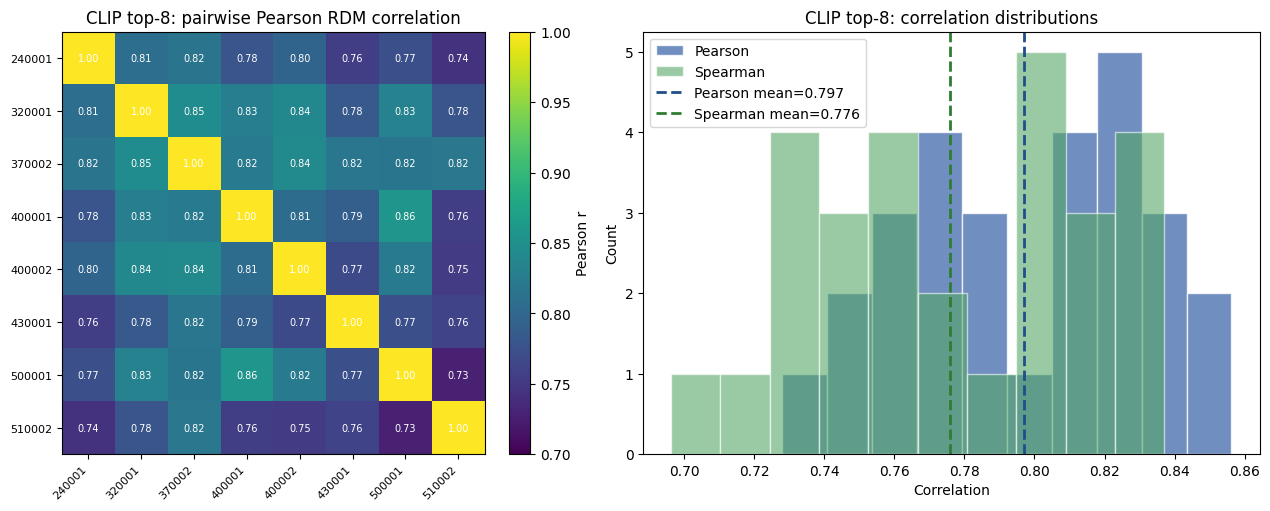

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/individual_rdm_pairwise_top8_heatmap_hist_clip_filtered-0.27_valid129.png
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/individual_rdm_pairwise_top8_heatmap_hist_clip_filtered-0.27_valid129.pdf
Mean Pearson r (clip, top-8): 0.796938
Mean Spearman rho (clip, top-8): 0.776009


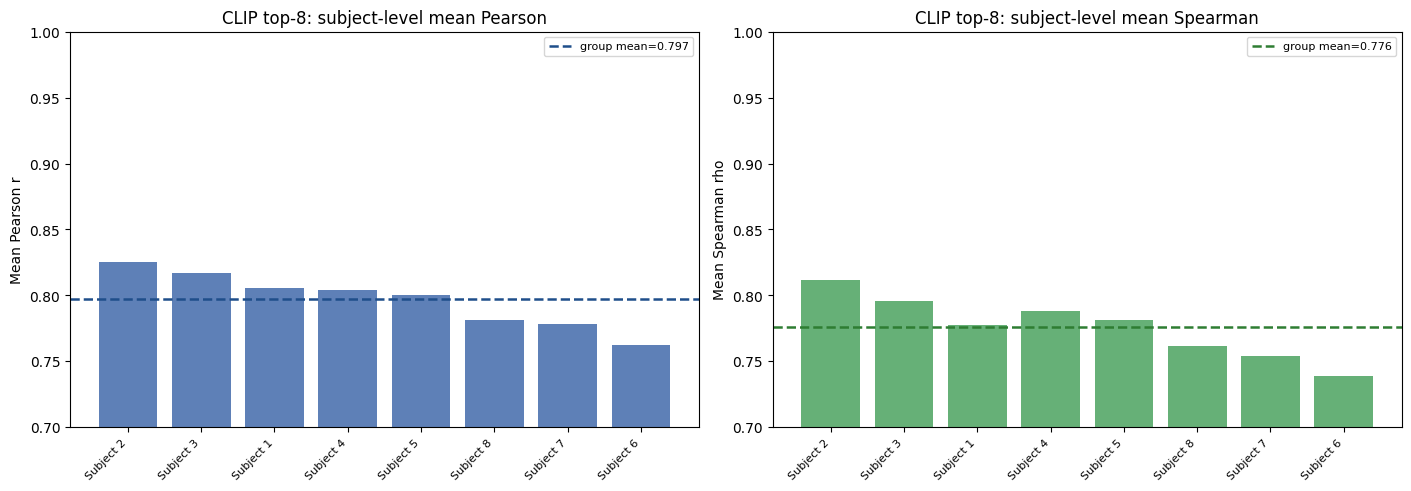

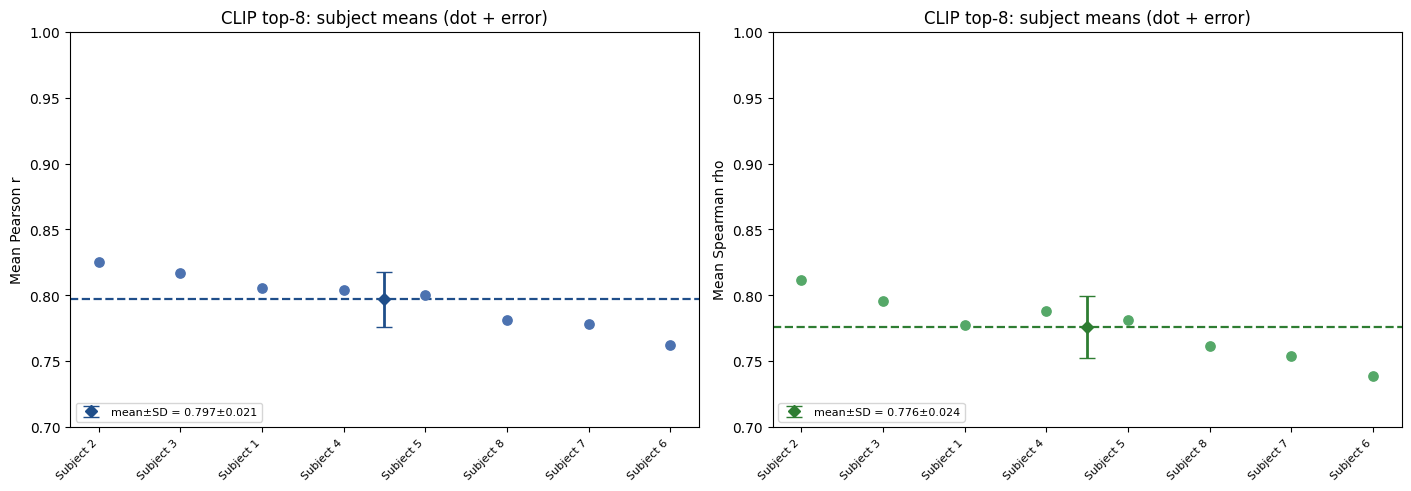

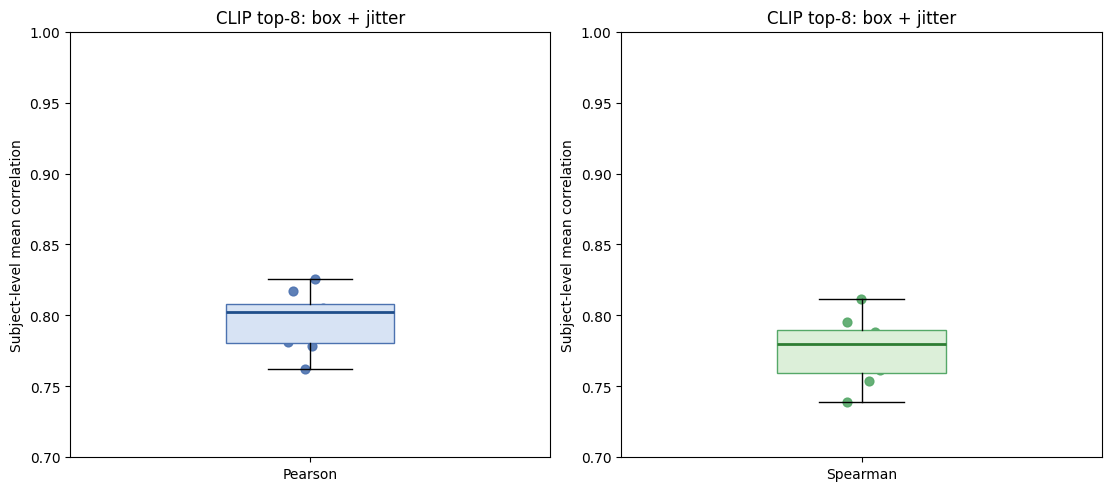

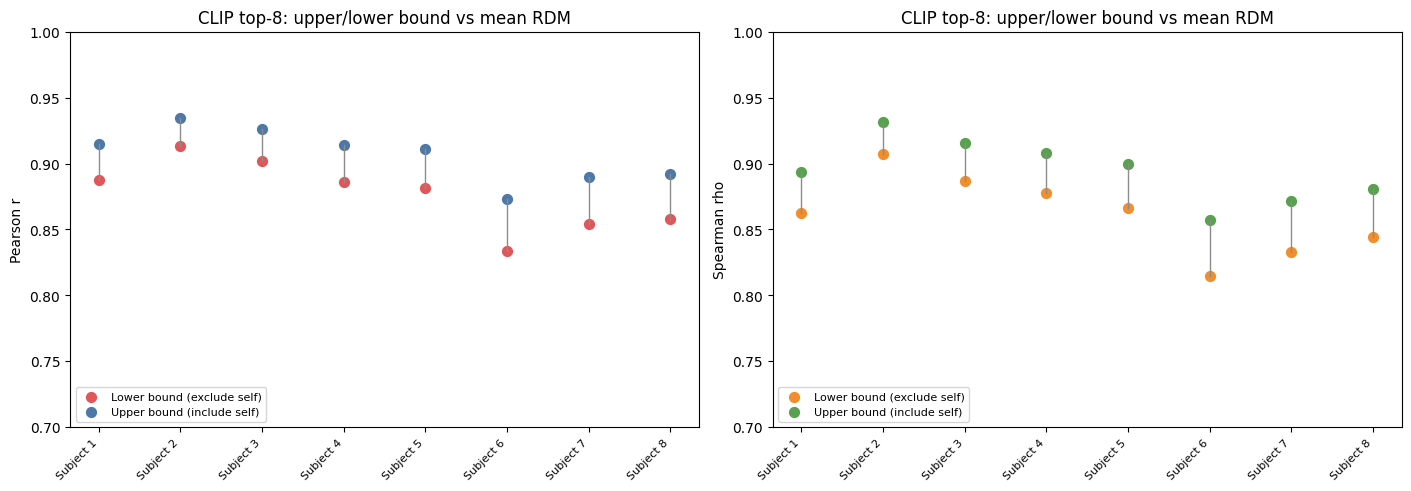

  subject  n_pairs  mean_pearson_r  mean_spearman_rho
Subject 2        7        0.825654           0.811471
Subject 3        7        0.816895           0.795382
Subject 1        7        0.805523           0.777424
Subject 4        7        0.804184           0.788091
Subject 5        7        0.800625           0.781583
Subject 8        7        0.781563           0.761445
Subject 7        7        0.778567           0.753835
Subject 6        7        0.762490           0.738844
  subject  n_categories_subject  n_pairs_upper  n_pairs_lower  upper_pearson_r  lower_pearson_r  upper_spearman_rho  lower_spearman_rho
Subject 1                   129           8256           8256         0.914712         0.887595            0.893201            0.862315
Subject 2                   129           8256           8256         0.934345         0.912920            0.931136            0.907241
Subject 3                   129           8256           8256         0.926238         0.901859           

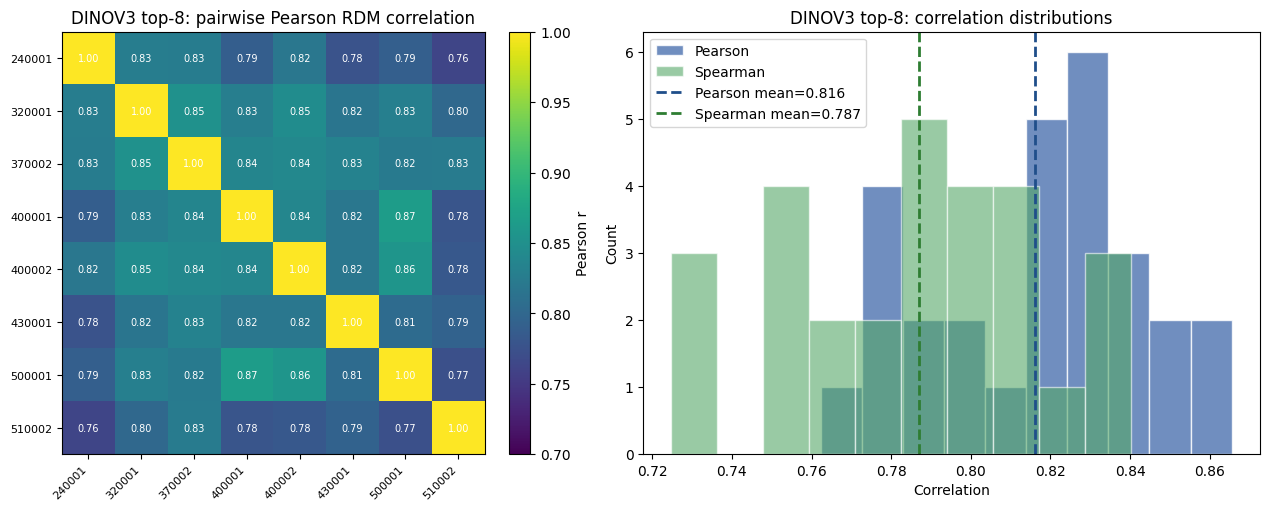

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/individual_rdm_pairwise_top8_heatmap_hist_dinov3_filtered-0.27_valid129.png
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/individual_rdm_pairwise_top8_heatmap_hist_dinov3_filtered-0.27_valid129.pdf
Mean Pearson r (dinov3, top-8): 0.816175
Mean Spearman rho (dinov3, top-8): 0.787068


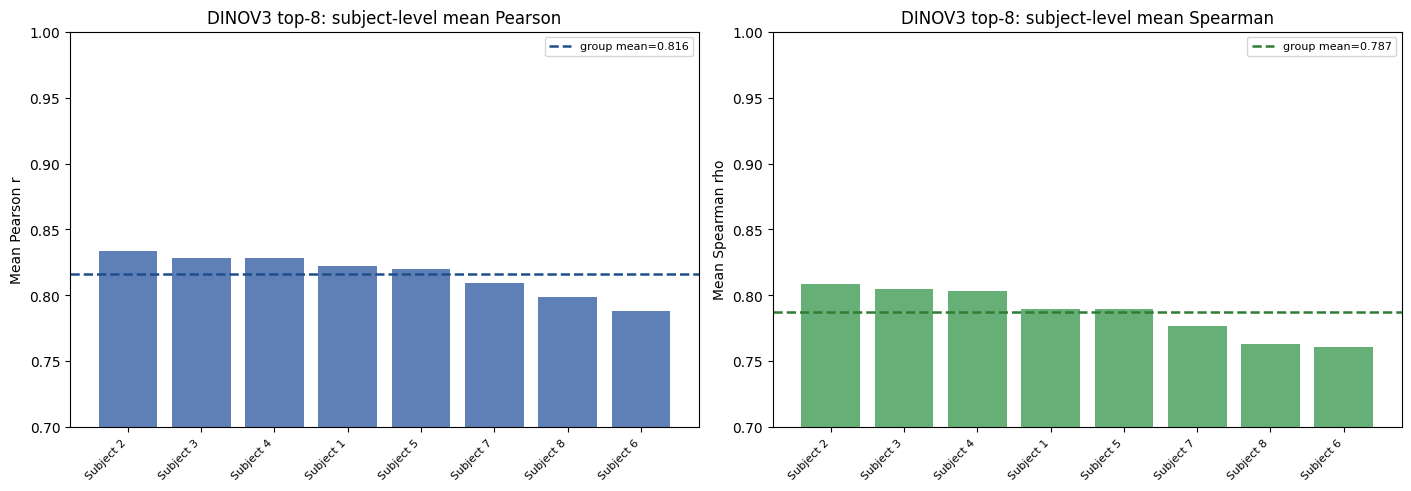

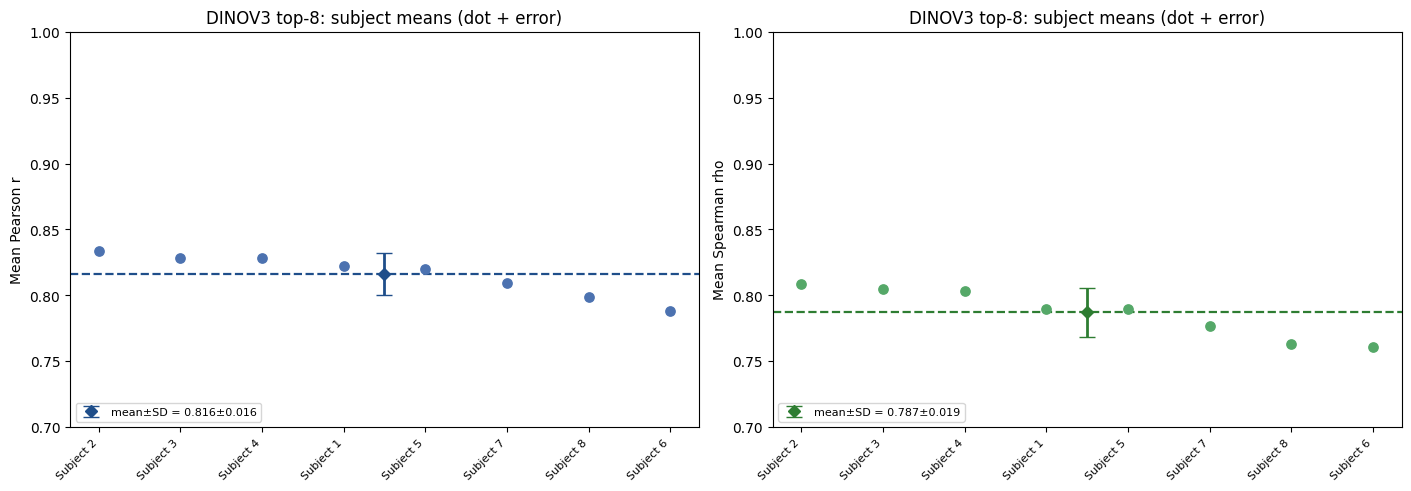

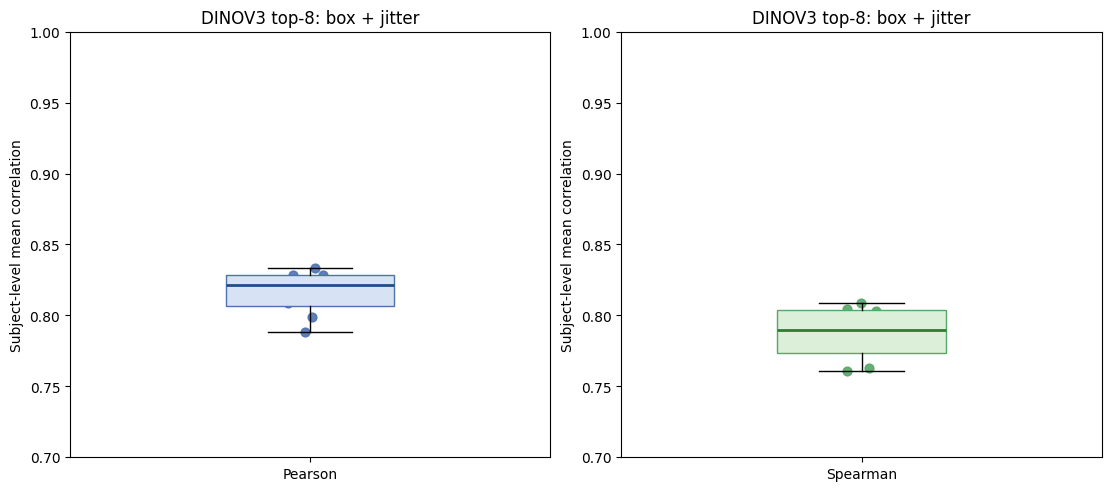

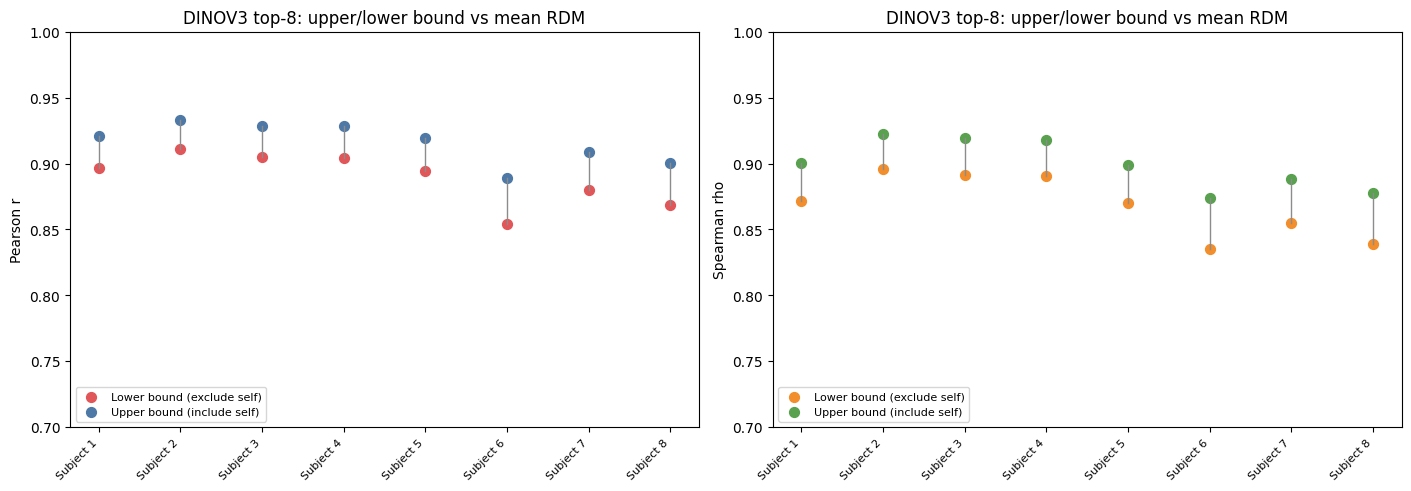

  subject  n_pairs  mean_pearson_r  mean_spearman_rho
Subject 2        7        0.833520           0.808949
Subject 3        7        0.828548           0.804834
Subject 4        7        0.828438           0.803249
Subject 1        7        0.822286           0.789758
Subject 5        7        0.820354           0.789299
Subject 7        7        0.809032           0.776947
Subject 8        7        0.798931           0.762994
Subject 6        7        0.788295           0.760515
  subject  n_categories_subject  n_pairs_upper  n_pairs_lower  upper_pearson_r  lower_pearson_r  upper_spearman_rho  lower_spearman_rho
Subject 1                   129           8256           8256         0.921067         0.896529            0.900101            0.871600
Subject 2                   129           8256           8256         0.932928         0.910735            0.922350            0.896051
Subject 3                   129           8256           8256         0.928544         0.904616           

In [20]:
# Visualization: top-8 pairwise correlations (heatmap + histogram) for each model
for model_name in MODEL_CONFIGS:
    _, _, category_to_idx = load_order(MODEL_CONFIGS[model_name]['order_csv'])
    pairwise_csv = all_results[model_name]['top8_pairwise_csv']
    plot_pairwise_top8_heatmap_hist(pairwise_csv, model_name=model_name)

    # Subject-level mean correlation in top-8 (each subject averaged across the other 7)
    pairwise_df = pd.read_csv(pairwise_csv, dtype={'subject_a': str, 'subject_b': str})
    pairwise_df['subject_a'] = pairwise_df['subject_a'].str.zfill(8)
    pairwise_df['subject_b'] = pairwise_df['subject_b'].str.zfill(8)
    top8_subjects = all_results[model_name]['top8_subjects']
    subject_label_map = {sid: f'Subject {i + 1}' for i, sid in enumerate(top8_subjects)}

    subject_rows = []
    for sid in top8_subjects:
        sid_df = pairwise_df[(pairwise_df['subject_a'] == sid) | (pairwise_df['subject_b'] == sid)]
        subject_rows.append({
            'subject': subject_label_map[sid],
            'n_pairs': int(len(sid_df)),
            'mean_pearson_r': float(sid_df['pearson_r'].mean()),
            'mean_spearman_rho': float(sid_df['spearman_rho'].mean()),
        })

    subject_mean_df = pd.DataFrame(subject_rows).sort_values('mean_pearson_r', ascending=False)
    if subject_mean_df['mean_pearson_r'].isna().all() or subject_mean_df['mean_spearman_rho'].isna().all():
        raise ValueError(
            f'All subject-level means are NaN for {model_name}. '
            'Check subject ID formatting in pairwise CSV versus top8_subjects list.'
        )
    out_csv = RESULTS_DIR / f'individual_rdm_top8_subject_level_mean_correlations_{model_name}_{RUN_SUFFIX}.csv'
    subject_mean_df.to_csv(out_csv, index=False)

    # Original visualization: bar plots (kept for continuity)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
    x = np.arange(len(subject_mean_df))
    labels = subject_mean_df['subject'].tolist()

    ax1.bar(x, subject_mean_df['mean_pearson_r'].values, color='#4C72B0', alpha=0.9)
    ax1.axhline(subject_mean_df['mean_pearson_r'].mean(), color='#1F4E8A', linestyle='--', linewidth=1.8,
               label=f"group mean={subject_mean_df['mean_pearson_r'].mean():.3f}")
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax1.set_ylim(0.7, 1.0)
    ax1.set_ylabel('Mean Pearson r')
    ax1.set_title(f'{model_name.upper()} top-8: subject-level mean Pearson')
    ax1.legend(fontsize=8)

    ax2.bar(x, subject_mean_df['mean_spearman_rho'].values, color='#55A868', alpha=0.9)
    ax2.axhline(subject_mean_df['mean_spearman_rho'].mean(), color='#2E7D32', linestyle='--', linewidth=1.8,
               label=f"group mean={subject_mean_df['mean_spearman_rho'].mean():.3f}")
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax2.set_ylim(0.7, 1.0)
    ax2.set_ylabel('Mean Spearman rho')
    ax2.set_title(f'{model_name.upper()} top-8: subject-level mean Spearman')
    ax2.legend(fontsize=8)

    out_png = FIGURES_DIR / f'individual_rdm_top8_subject_level_mean_correlations_{model_name}_{RUN_SUFFIX}.png'
    out_pdf = FIGURES_DIR / f'individual_rdm_top8_subject_level_mean_correlations_{model_name}_{RUN_SUFFIX}.pdf'
    fig.savefig(out_png, dpi=220, bbox_inches='tight')
    fig.savefig(out_pdf, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    # Spread visualization A: dot + error bar (group mean ± SD)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
    x = np.arange(len(subject_mean_df))
    labels = subject_mean_df['subject'].tolist()

    pearson_vals = subject_mean_df['mean_pearson_r'].values
    spearman_vals = subject_mean_df['mean_spearman_rho'].values

    ax1.scatter(x, pearson_vals, color='#4C72B0', s=45, zorder=3)
    ax1.errorbar(
        x=np.mean(x),
        y=np.mean(pearson_vals),
        yerr=np.std(pearson_vals, ddof=1),
        fmt='D', color='#1F4E8A', ecolor='#1F4E8A', capsize=6, elinewidth=2,
        label=f"mean±SD = {np.mean(pearson_vals):.3f}±{np.std(pearson_vals, ddof=1):.3f}",
    )
    ax1.axhline(np.mean(pearson_vals), color='#1F4E8A', linestyle='--', linewidth=1.6)
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax1.set_ylim(0.7, 1.0)
    ax1.set_ylabel('Mean Pearson r')
    ax1.set_title(f'{model_name.upper()} top-8: subject means (dot + error)')
    ax1.legend(fontsize=8, loc='lower left')

    ax2.scatter(x, spearman_vals, color='#55A868', s=45, zorder=3)
    ax2.errorbar(
        x=np.mean(x),
        y=np.mean(spearman_vals),
        yerr=np.std(spearman_vals, ddof=1),
        fmt='D', color='#2E7D32', ecolor='#2E7D32', capsize=6, elinewidth=2,
        label=f"mean±SD = {np.mean(spearman_vals):.3f}±{np.std(spearman_vals, ddof=1):.3f}",
    )
    ax2.axhline(np.mean(spearman_vals), color='#2E7D32', linestyle='--', linewidth=1.6)
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax2.set_ylim(0.7, 1.0)
    ax2.set_ylabel('Mean Spearman rho')
    ax2.set_title(f'{model_name.upper()} top-8: subject means (dot + error)')
    ax2.legend(fontsize=8, loc='lower left')

    out_png = FIGURES_DIR / f'individual_rdm_top8_subject_level_mean_correlations_dot_error_{model_name}_{RUN_SUFFIX}.png'
    out_pdf = FIGURES_DIR / f'individual_rdm_top8_subject_level_mean_correlations_dot_error_{model_name}_{RUN_SUFFIX}.pdf'
    fig.savefig(out_png, dpi=220, bbox_inches='tight')
    fig.savefig(out_pdf, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    # Spread visualization B: boxplot + jittered points
    rng = np.random.default_rng(42)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)

    ax1.boxplot(pearson_vals, widths=0.35, patch_artist=True, boxprops=dict(facecolor='#D7E3F4', color='#4C72B0'), medianprops=dict(color='#1F4E8A', linewidth=2))
    j1 = rng.normal(1, 0.035, size=len(pearson_vals))
    ax1.scatter(j1, pearson_vals, color='#4C72B0', s=40, alpha=0.9)
    ax1.set_xticks([1])
    ax1.set_xticklabels(['Pearson'])
    ax1.set_ylim(0.7, 1.0)
    ax1.set_ylabel('Subject-level mean correlation')
    ax1.set_title(f'{model_name.upper()} top-8: box + jitter')

    ax2.boxplot(spearman_vals, widths=0.35, patch_artist=True, boxprops=dict(facecolor='#DCEFD9', color='#55A868'), medianprops=dict(color='#2E7D32', linewidth=2))
    j2 = rng.normal(1, 0.035, size=len(spearman_vals))
    ax2.scatter(j2, spearman_vals, color='#55A868', s=40, alpha=0.9)
    ax2.set_xticks([1])
    ax2.set_xticklabels(['Spearman'])
    ax2.set_ylim(0.7, 1.0)
    ax2.set_ylabel('Subject-level mean correlation')
    ax2.set_title(f'{model_name.upper()} top-8: box + jitter')

    out_png = FIGURES_DIR / f'individual_rdm_top8_subject_level_mean_correlations_box_jitter_{model_name}_{RUN_SUFFIX}.png'
    out_pdf = FIGURES_DIR / f'individual_rdm_top8_subject_level_mean_correlations_box_jitter_{model_name}_{RUN_SUFFIX}.pdf'
    fig.savefig(out_png, dpi=220, bbox_inches='tight')
    fig.savefig(out_pdf, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    # Upper/lower bounds: correlation to top-8 average RDM (include-self vs exclude-self)
    subject_rdms = all_results[model_name]['subject_rdms']
    subject_available = all_results[model_name]['subject_available']
    bound_rows = []

    for sid in top8_subjects:
        idx = [category_to_idx[c] for c in sorted(subject_available[sid])]
        if len(idx) < 3:
            continue

        target_sub = subject_rdms[sid][np.ix_(idx, idx)]
        target_vec = target_sub[np.tril_indices(len(idx), k=-1)]

        include_stack = np.stack([subject_rdms[s][np.ix_(idx, idx)] for s in top8_subjects], axis=0)
        include_mean = np.nanmean(include_stack, axis=0)
        include_vec = include_mean[np.tril_indices(len(idx), k=-1)]

        others = [s for s in top8_subjects if s != sid]
        exclude_stack = np.stack([subject_rdms[s][np.ix_(idx, idx)] for s in others], axis=0)
        exclude_mean = np.nanmean(exclude_stack, axis=0)
        exclude_vec = exclude_mean[np.tril_indices(len(idx), k=-1)]

        m_up = np.isfinite(target_vec) & np.isfinite(include_vec)
        m_lo = np.isfinite(target_vec) & np.isfinite(exclude_vec)

        up_pr = pearsonr(target_vec[m_up], include_vec[m_up])[0] if np.sum(m_up) >= 3 else np.nan
        lo_pr = pearsonr(target_vec[m_lo], exclude_vec[m_lo])[0] if np.sum(m_lo) >= 3 else np.nan
        up_sr = spearmanr(target_vec[m_up], include_vec[m_up])[0] if np.sum(m_up) >= 3 else np.nan
        lo_sr = spearmanr(target_vec[m_lo], exclude_vec[m_lo])[0] if np.sum(m_lo) >= 3 else np.nan

        bound_rows.append({
            'subject': subject_label_map[sid],
            'n_categories_subject': len(idx),
            'n_pairs_upper': int(np.sum(m_up)),
            'n_pairs_lower': int(np.sum(m_lo)),
            'upper_pearson_r': float(up_pr) if pd.notna(up_pr) else np.nan,
            'lower_pearson_r': float(lo_pr) if pd.notna(lo_pr) else np.nan,
            'upper_spearman_rho': float(up_sr) if pd.notna(up_sr) else np.nan,
            'lower_spearman_rho': float(lo_sr) if pd.notna(lo_sr) else np.nan,
        })

    bounds_df = pd.DataFrame(bound_rows).sort_values('subject')
    bounds_csv = RESULTS_DIR / f'individual_rdm_top8_upper_lower_bounds_{model_name}_{RUN_SUFFIX}.csv'
    bounds_df.to_csv(bounds_csv, index=False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
    bx = np.arange(len(bounds_df))
    blabels = bounds_df['subject'].tolist()

    ax1.scatter(bx, bounds_df['lower_pearson_r'].values, color='#E15759', s=50, label='Lower bound (exclude self)')
    ax1.scatter(bx, bounds_df['upper_pearson_r'].values, color='#4E79A7', s=50, label='Upper bound (include self)')
    for i in range(len(bounds_df)):
        ax1.plot([bx[i], bx[i]], [bounds_df['lower_pearson_r'].iloc[i], bounds_df['upper_pearson_r'].iloc[i]], color='0.55', linewidth=1)
    ax1.set_xticks(bx)
    ax1.set_xticklabels(blabels, rotation=45, ha='right', fontsize=8)
    ax1.set_ylim(0.7, 1.0)
    ax1.set_ylabel('Pearson r')
    ax1.set_title(f'{model_name.upper()} top-8: upper/lower bound vs mean RDM')
    ax1.legend(fontsize=8, loc='lower left')

    ax2.scatter(bx, bounds_df['lower_spearman_rho'].values, color='#F28E2B', s=50, label='Lower bound (exclude self)')
    ax2.scatter(bx, bounds_df['upper_spearman_rho'].values, color='#59A14F', s=50, label='Upper bound (include self)')
    for i in range(len(bounds_df)):
        ax2.plot([bx[i], bx[i]], [bounds_df['lower_spearman_rho'].iloc[i], bounds_df['upper_spearman_rho'].iloc[i]], color='0.55', linewidth=1)
    ax2.set_xticks(bx)
    ax2.set_xticklabels(blabels, rotation=45, ha='right', fontsize=8)
    ax2.set_ylim(0.7, 1.0)
    ax2.set_ylabel('Spearman rho')
    ax2.set_title(f'{model_name.upper()} top-8: upper/lower bound vs mean RDM')
    ax2.legend(fontsize=8, loc='lower left')

    bounds_png = FIGURES_DIR / f'individual_rdm_top8_upper_lower_bounds_{model_name}_{RUN_SUFFIX}.png'
    bounds_pdf = FIGURES_DIR / f'individual_rdm_top8_upper_lower_bounds_{model_name}_{RUN_SUFFIX}.pdf'
    fig.savefig(bounds_png, dpi=220, bbox_inches='tight')
    fig.savefig(bounds_pdf, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(subject_mean_df.to_string(index=False))
    print(bounds_df.to_string(index=False))
    print(f'Saved: {out_csv}')
    print(f'Saved: {bounds_csv}')
    print(f'Saved: {bounds_png}')
    print(f'Saved: {bounds_pdf}')

Notes:
- Every RDM is indexed by each model's notebook-03 order file (`bv_things_rdm_order_bv_semantic_<model>_filtered-0.27_valid129.csv` under `main_results_valid129s_04302026/results/`).
- Missing categories remain `NaN` and render as empty/white cells.
- Pairwise comparisons are computed only on common categories per subject pair, with that model's fixed master ordering.
- Both Pearson and Spearman metrics are exported in pairwise CSVs and summary outputs.

## MDS vs THINGS (explicit section)

This section makes the MDS outputs explicit after the main run:
- shows MDS summary table
- verifies per-model files exist
- displays saved MDS figures for CLIP and DINOv3

In [21]:
# Explicit MDS outputs (after running the main model loop cell)
from IPython.display import display, Image

print('Using updated explicit MDS cell (no hard RuntimeError).')

summary_candidates = []
expected = RESULTS_DIR / f'mds_individual_rdms_vs_things_summary_clip_dinov3_{RUN_SUFFIX}.csv'
if expected.exists():
    summary_candidates.append(expected)
summary_candidates.extend(sorted(RESULTS_DIR.glob('mds_individual_rdms_vs_things_summary_clip_dinov3_filtered-*.csv')))

if 'mds_summary_df' not in globals():
    if len(summary_candidates) > 0:
        # Use newest candidate if exact token file is missing
        mds_summary_csv = max(summary_candidates, key=lambda p: p.stat().st_mtime)
        mds_summary_df = pd.read_csv(mds_summary_csv)
        print(f'Loaded MDS summary from: {mds_summary_csv}')
    else:
        print('No MDS summary CSV found yet. Run the main analysis cell first (the model loop) to generate MDS outputs.')
        mds_summary_df = pd.DataFrame()

if len(mds_summary_df) > 0:
    display(mds_summary_df)

for model_name in MODEL_CONFIGS:
    # Try exact token first, then fallback glob
    png1 = FIGURES_DIR / f'mds_individual_rdms_vs_things_{model_name}_{RUN_SUFFIX}.png'
    png2 = FIGURES_DIR / f'mds_individual_rdms_vs_things_colored_{model_name}_{RUN_SUFFIX}.png'

    if not png1.exists():
        cands1 = sorted(FIGURES_DIR.glob(f'mds_individual_rdms_vs_things_{model_name}_filtered-*.png'))
        if cands1:
            png1 = max(cands1, key=lambda p: p.stat().st_mtime)

    if not png2.exists():
        cands2 = sorted(FIGURES_DIR.glob(f'mds_individual_rdms_vs_things_colored_{model_name}_filtered-*.png'))
        if cands2:
            png2 = max(cands2, key=lambda p: p.stat().st_mtime)

    print(f'[{model_name}] plot1={png1} (exists={png1.exists()})')
    print(f'[{model_name}] plot2={png2} (exists={png2.exists()})')
    if png1.exists():
        display(Image(filename=str(png1)))
    if png2.exists():
        display(Image(filename=str(png2)))


Using updated explicit MDS cell (no hard RuntimeError).
[clip] plot1=/home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/mds_individual_rdms_vs_things_clip_filtered-0.27_valid129.png (exists=False)
[clip] plot2=/home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/mds_individual_rdms_vs_things_colored_clip_filtered-0.27_valid129.png (exists=False)
[dinov3] plot1=/home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/mds_individual_rdms_vs_things_dinov3_filtered-0.27_valid129.png (exists=False)
[dinov3] plot2=/home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/mds_individual_rdms_vs_things_colored_dinov3_filtered-0.27_valid129.png (exists=False)
